## Getting Started with PMG and ASE!
Both ASE (atomic simulation environment) and PMG (python materials genomic) are libraries that contain powerful tools for all things atomistic calculations. They have lots of overlaps in functionalities, but ASE does some things better (or more efficient) than PMG, and vice-versa

## Generating structures through code
Aside from obtaining structure files (.cif, .xyz, etc) from databases like c2db (https://c2db.fysik.dtu.dk/) and materials project (https://next-gen.materialsproject.org/), ASE and PMG can be used to generate them. Below will contain a couple snippets generating different bulk metals and metals in different orientations as well as monolayer structures with ASE only then with PMG.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ase.build import bulk, fcc111, hcp0001, mx2
from ase.visualize.plot import plot_atoms
from ase.geometry import cell_to_cellpar

In [3]:
def show_atoms(atoms, title="", rotation="0x,0y,0z", radii=0.55, scale=0.75):
    """
    Inline ASE visualization for notebooks using ase.visualize.plot.plot_atoms.
    rotation:
      '0x,0y,0z'   -> top view, looking along z
      '90x,0y,0z'  -> side view
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    plot_atoms(
        atoms,
        ax,
        rotation=rotation,
        radii=radii,
        scale=scale,
        show_unit_cell=2,
    )
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()


def print_cell(atoms, name):
    a, b, c, alpha, beta, gamma = atoms.cell.cellpar()
    print(f"{name}")
    print(f"  atoms: {len(atoms)}")
    print(f"  cell lengths: a={a:.3f} Å, b={b:.3f} Å, c={c:.3f} Å")
    print(f"  cell angles : alpha={alpha:.2f}°, beta={beta:.2f}°, gamma={gamma:.2f}°")
    print(f"  pbc         : {atoms.pbc}")

In [4]:
a_Au = 4.078       # fcc Au conventional cubic lattice constant
a_Ti = 2.951       # hcp Ti basal-plane lattice constant
c_Ti = 4.683       # hcp Ti c lattice constant

a_MoS2 = 3.18      # in-plane lattice constant for monolayer 2H-MoS2
t_MoS2 = 3.19      # vertical S-S thickness used by ASE mx2
vacuum = 15.0

In [5]:
Au_bulk = bulk("Au", "fcc", a=a_Au, cubic=True).repeat((2, 2, 2))
Ti_bulk = bulk("Ti", "hcp", a=a_Ti, c=c_Ti).repeat((3, 3, 2))

print_cell(Au_bulk, "Bulk Au, fcc")
print_cell(Ti_bulk, "Bulk Ti, hcp")

Bulk Au, fcc
  atoms: 32
  cell lengths: a=8.156 Å, b=8.156 Å, c=8.156 Å
  cell angles : alpha=90.00°, beta=90.00°, gamma=90.00°
  pbc         : [ True  True  True]
Bulk Ti, hcp
  atoms: 36
  cell lengths: a=8.853 Å, b=8.853 Å, c=9.366 Å
  cell angles : alpha=90.00°, beta=90.00°, gamma=120.00°
  pbc         : [ True  True  True]


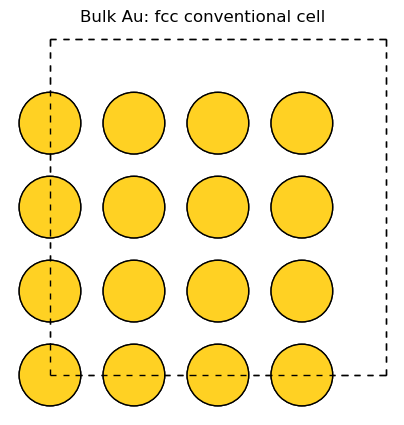

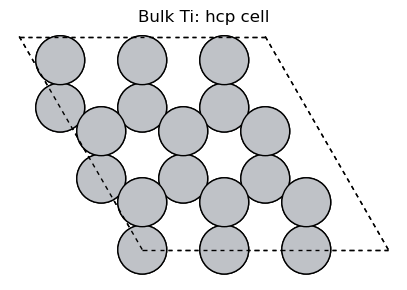

In [9]:
show_atoms(Au_bulk, "Bulk Au: fcc conventional cell", rotation="0x,0y,0z")
show_atoms(Ti_bulk, "Bulk Ti: hcp cell", rotation="0x,0y,0z")

Au(111) slab
  atoms: 4
  cell lengths: a=2.884 Å, b=2.884 Å, c=37.063 Å
  cell angles : alpha=90.00°, beta=90.00°, gamma=60.00°
  pbc         : [ True  True  True]
Ti(0001) slab
  atoms: 4
  cell lengths: a=2.951 Å, b=2.951 Å, c=37.025 Å
  cell angles : alpha=90.00°, beta=90.00°, gamma=60.00°
  pbc         : [ True  True  True]


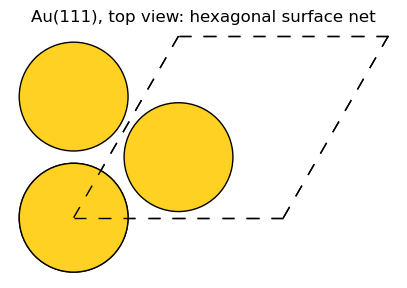

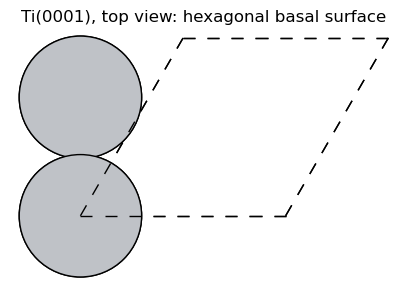

In [28]:
Au111 = fcc111(
    "Au",
    size=(1, 1, 4),   # x repeats, y repeats, slab layers
    a=a_Au,
    vacuum=vacuum,
    periodic=True,
)

Ti0001 = hcp0001(
    "Ti",
    size=(1, 1, 4),
    a=a_Ti,
    c=c_Ti,
    vacuum=vacuum,
    periodic=True,
)

print_cell(Au111, "Au(111) slab")
print_cell(Ti0001, "Ti(0001) slab")
show_atoms(Au111, "Au(111), top view: hexagonal surface net", rotation="0x,0y,0z")
#show_atoms(Au111, "Au(111), side view: slab + vacuum", rotation="90x,0y,0z")

show_atoms(Ti0001, "Ti(0001), top view: hexagonal basal surface", rotation="0x,0y,0z")
#show_atoms(Ti0001, "Ti(0001), side view: slab + vacuum", rotation="90x,0y,0z")

Monolayer 2H-MoS2
  atoms: 3
  cell lengths: a=3.180 Å, b=3.180 Å, c=33.190 Å
  cell angles : alpha=90.00°, beta=90.00°, gamma=120.00°
  pbc         : [ True  True False]


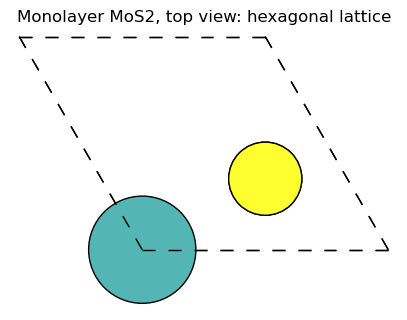

In [29]:
MoS2 = mx2(
    formula="MoS2",
    kind="2H",
    a=a_MoS2,
    thickness=t_MoS2,
    size=(1, 1, 1),
    vacuum=vacuum,
)

# For a 2D monolayer, x and y are periodic. z can be left periodic with vacuum
MoS2.pbc = (True, True, False)

print_cell(MoS2, "Monolayer 2H-MoS2")
show_atoms(MoS2, "Monolayer MoS2, top view: hexagonal lattice", rotation="0x,0y,0z", radii=0.45)
#show_atoms(MoS2, "Monolayer MoS2, side view: S-Mo-S trilayer", rotation="90x,0y,0z", radii=0.45)

In [30]:
from ase.io import write

# Save the structure as an POSCAR file or .xyz
write('../examples/structures/Au_111.vasp', Au111)
write('../examples/structures/Ti_0001.vasp', Ti0001)
write('../examples/structures/MoS2.vasp', MoS2)

write('../examples/structures/Au_111.cif', Au111)
write('../examples/structures/Ti_0001.cif', Ti0001)
write('../examples/structures/MoS2.cif', MoS2)
